In [42]:
import numpy as np
import matplotlib.pyplot as plt

In [43]:
def f(x):
  return 5*x + 15

In [44]:
X = np.random.rand(100, 1)
Y = f(X)

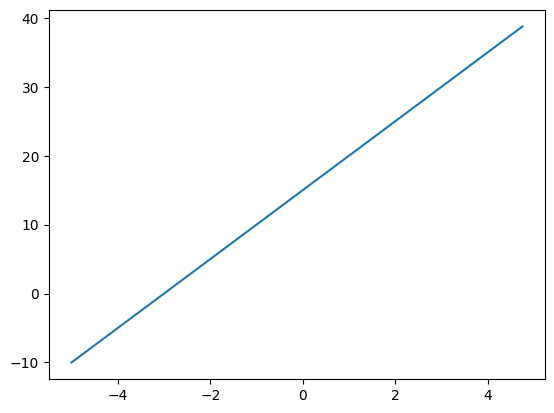

In [45]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [46]:
class LineerRegression:
    def __init__(self, lr = 0.001, epochs = 10000):
        self.lr = lr
        self.epochs = epochs
        self.w = None # Weight
        self.b = None # Bias

    def dot_product(self, X, w, b):
        m = len(X) # How many samples
        predictions = []

        for i in range(m):
            x_i = X[i]
            dot = 0.0
            for j in range(len(x_i)):
                dot += x_i[j] * w[j][0]
            y_hat = dot + b
            predictions.append([y_hat])

        return predictions
    
    def compute_gradients(self, X, error):
        m = len(X)
        dw = 0.0 # Gradient of w
        db = 0.0 # Gradient of b

        for i in range(m):
            xi = X[i][0]
            ei = error[i][0]

            dw += xi * ei
            db += ei

        dw = (2/m) * dw
        db = (2/m) * db

        return dw, db

    def fit(self, X, Y):
        m, n = X.shape
        self.w = np.zeros((n, 1))
        self.b = 0

        for epoch in range(self.epochs+1):
            y_pred = self.dot_product(X, self.w, self.b)
            error = y_pred - Y

            dw, db = self.compute_gradients(X, error)

            self.w -= self.lr * dw 
            self.b -= self.lr * db

            if epoch % 100 == 0:
                loss = np.mean(error ** 2)
                print(f"Epoch {epoch} | Loss: {loss:.4f} | w: {self.w[0][0]:.4f} | b: {self.b:.4f} | f(x): {self.w[0][0]}x + {self.b:.4f} ")

    def predict(self, X):
        return X.dot(self.w) + self.b


In [47]:
lr = LineerRegression()
train = lr.fit(X, Y)
train

Epoch 0 | Loss: 312.6427 | w: 0.0194 | b: 0.0352 | f(x): 0.01935909318479364x + 0.0352 
Epoch 100 | Loss: 186.3753 | w: 1.7182 | b: 3.1371 | f(x): 1.71820004646132x + 3.1371 
Epoch 200 | Loss: 111.1949 | w: 3.0211 | b: 5.5350 | f(x): 3.021065268362225x + 5.5350 
Epoch 300 | Loss: 66.4294 | w: 4.0185 | b: 7.3896 | f(x): 4.018511697081925x + 7.3896 
Epoch 400 | Loss: 39.7717 | w: 4.7804 | b: 8.8249 | f(x): 4.780410649111971x + 8.8249 
Epoch 500 | Loss: 23.8947 | w: 5.3607 | b: 9.9367 | f(x): 5.360672626173521x + 9.9367 
Epoch 600 | Loss: 14.4362 | w: 5.8009 | b: 10.7987 | f(x): 5.800892932896139x + 10.7987 
Epoch 700 | Loss: 8.7992 | w: 6.1332 | b: 11.4681 | f(x): 6.133164601901759x + 11.4681 
Epoch 800 | Loss: 5.4374 | w: 6.3822 | b: 11.9886 | f(x): 6.382248820870587x + 11.9886 
Epoch 900 | Loss: 3.4304 | w: 6.5672 | b: 12.3943 | f(x): 6.567249613992287x + 12.3943 
Epoch 1000 | Loss: 2.2300 | w: 6.7029 | b: 12.7114 | f(x): 6.702906010620116x + 12.7114 
Epoch 1100 | Loss: 1.5101 | w: 6.8

In [48]:
dummy_data = np.array([[1], [2], [3], [4], [5]]) # Expected Outputs: 20, 25, 30, 35, 40
predictions = lr.predict(dummy_data)

predictions

array([[20.2748194 ],
       [25.90431696],
       [31.53381453],
       [37.1633121 ],
       [42.79280967]])

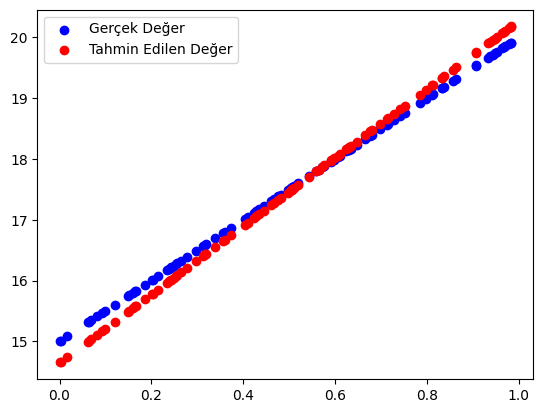

In [ ]:
X_test = np.random.rand(100, 1)
Y_test = f(X_test)
Y_pred = lr.predict(X_test)

plt.scatter(X_test, Y_test, color='blue', label='Gerçek Değer')
plt.scatter(X_test, Y_pred, color='red', label='Tahmin Edilen Değer')
plt.legend()
plt.show()